In [3]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px # for interactive plots

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram

In [4]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/xgboost.csv")  # for variogram, etc.
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering/xgboost
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Soil_N', 'pr_irrigated', 

/tmp/ipykernel_42716/668219514.py:4: DtypeWarning: Columns (6,7,13,14,15,16,17,20,22,23,29,31,33,34,35,36,37,44,45,70,74,75,76) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/xgboost.csv")  # for variogram, etc.


In [5]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Continent",
    "Latitude..N.S.", "Longitude..E.W.",
    "Location.source", "Observation.period", "X", "Y", "unit_code"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = []

# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (69532, 95)
Shape after dropping: (69532, 69)
Dropped columns: ['id', 'Planting.date', 'Emissions..yes.no.', 'Data.ID', 'Irrigation..mm.', 'Planting.date.1', 'Agricultural_Use_–_Rodenticides_(t)', 'irr_end_date', 'end_date', 'State.Region.County.Province', 'Continent', 'Location', 'Treatment.type', 'Observation.period', 'Agricultural_Use_–_Other_Pesticides_nes_(t)', 'harvest_week', 'Location.source', 'Longitude..E.W.', 'harvest_date_clean', 'rainfed_end_date', 'Harvesting.date.1', 'harvest_month', 'Latitude..N.S.', 'Planting_Week', 'Pest.severity.score.......66', 'Planting_Month']
Remaining columns: ['Country', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.

In [6]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df_cleaned[col])}
        for col in df_cleaned.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Country                                               | object  |   69532 |          100   |         39 |
| Conversion.for.longitude                              | float64 |   69532 |          100   |        240 |
| year                                                  | int64   |   69532 |          100   |         15 |
| pr_irrigated                                          | float64 |   69530 |          100   |        191 |
| start_date                                            | int64   |   69532 |          100   |          7 |
| Grain.yield..tons.ha.1.                               | float64 |   69532 |          100   |      14886 |
| Conversion.for.latitude                               | float64 |   69532 |          100   |        240 |
| Elevation                 

Find columns to impute with spacially aware KNNs

In [7]:
# Get all columns with <99% completeness
cols_to_impute = summary_long.loc[summary_long['pct_complete'] < 99, 'variable'].tolist()

# Ensure 'observation_date' is included
if 'year' in df_cleaned.columns and 'year' not in cols_to_impute:
    cols_to_impute.append('year')

# Subset the cleaned DataFrame
df_toimpute = df_cleaned[cols_to_impute]

print(df_toimpute.head())

   Agricultural_Use_–_Pesticides_(total)_(t)  \
0                                   374818.2   
1                                   374818.2   
2                                   374818.2   
3                                   374818.2   
4                                   374818.2   

   Agricultural_Use_–_Insecticides_(t)  Year_x  \
0                             63956.47  2010.0   
1                             63956.47  2010.0   
2                             63956.47  2010.0   
3                             63956.47  2010.0   
4                             63956.47  2010.0   

   Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha)  \
0                                               2.28       
1                                               2.28       
2                                               2.28       
3                                               2.28       
4                                               2.28       

   Agricultural_Use_–_Herbicides_(t)  \
0        

continous features

In [85]:

#Select columns with continous features
df_toimpute_continous = df_toimpute.select_dtypes(include=['number'])

print(df_toimpute_continous)

       N.rate..kg.N.ha.1.  drydays(annualsum)  dryspells(5days)  year
0                     0.0           298.00037         15.000123  2010
1                    91.0           298.00037         15.000123  2010
2                   151.0           298.00037         15.000123  2010
3                   203.0           298.00037         15.000123  2010
4                   254.0           298.00037         15.000123  2010
...                   ...                 ...               ...   ...
69527                 NaN                 NaN               NaN  2019
69528                 NaN                 NaN               NaN  2019
69529                 NaN                 NaN               NaN  2019
69530                 NaN                 NaN               NaN  2019
69531                 NaN                 NaN               NaN  2019

[69532 rows x 4 columns]


In [77]:
# Drop inherently noisy columns or columns that can't be reliably imputed
cols_to_drop = [
	"rainfed_start_date",
	"irr_start_date",
	"Mean.annual.precipitation..mm.",
	"hdi",
	"gdp",
	"Irrigation.mm_clean",
	"harvest_dayofyear",
	"Mean.annual.temperature..Â.C.",
	"Agricultural_Use_–_Pesticides_(total)_(t)",
	"Year_x", 
	"P.rate..kg.P.ha.1.",
	"Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha)",
	"Agricultural_Use_–_Insecticides_(t)",
	"Agricultural_Use_–_Herbicides_(t)",
	"Agricultural_Use_–_Fungicides_and_Bactericides_(t)"
]
df_toimpute_continous = df_toimpute_continous.drop(
	columns=[col for col in cols_to_drop if col in df_toimpute_continous.columns]
)


In [78]:
print(df_toimpute_continous.head())

   N.rate..kg.N.ha.1.  drydays(annualsum)  dryspells(5days)  year
0                 0.0           298.00037         15.000123  2010
1                91.0           298.00037         15.000123  2010
2               151.0           298.00037         15.000123  2010
3               203.0           298.00037         15.000123  2010
4               254.0           298.00037         15.000123  2010


In [79]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df_toimpute_continous[col])}
        for col in df_toimpute_continous.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable           | dtype   |   count |   pct_complete |   n_unique |
|--------------------|---------|---------|----------------|------------|
| year               | int64   |   69532 |          100   |         15 |
| N.rate..kg.N.ha.1. | float64 |   63617 |           91.5 |        196 |
| drydays(annualsum) | float64 |   62144 |           89.4 |        445 |
| dryspells(5days)   | float64 |   62144 |           89.4 |        426 |


In [80]:
# Step 1: Compute completeness per year
completeness_over_time = (
    df_toimpute_continous
    .groupby('year')
    .apply(lambda group: group.notna().mean() * 100)
)

# Step 2: Transpose for plotting
completeness_over_time = completeness_over_time.T

# Step 3: Filter features with average completeness <= 90%
low_quality_features = completeness_over_time.mean(axis=1) <= 95
completeness_over_time = completeness_over_time[low_quality_features]

# Step 4: Reshape to long format
completeness_long = completeness_over_time.reset_index().melt(
    id_vars='index',
    var_name='year',
    value_name='pct_complete'
).rename(columns={'index': 'feature'})

# Step 5: Plot with hover-isolate enabled
fig = px.line(
    completeness_long,
    x='year',
    y='pct_complete',
    color='feature',
    hover_name='feature',
    labels={'pct_complete': 'Percent Complete (%)', 'year': 'Year'},
    title='Feature Data Completeness Over Time (≤90% Avg Completeness)'
)

# Enable hover isolation
fig.update_traces(mode='lines+markers', hoverinfo='all', opacity=0.7)
fig.update_layout(
    height=600,
    width=1000,
    hovermode='x unified',  # unified x hover
    legend_title='Feature',
    legend=dict(itemclick="toggleothers")  # clicking one legend hides others
)

fig.show()

/tmp/ipykernel_23775/4188466842.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



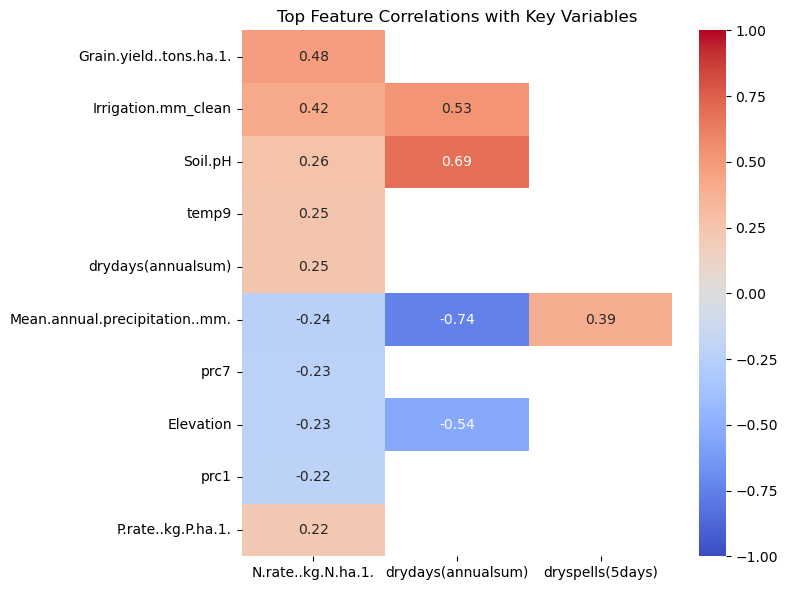

In [8]:
# Select float columns
float_cols = df_cleaned.select_dtypes(include=['float64', 'float32'])

# Compute correlation matrix
corr_matrix = float_cols.corr(method='pearson')

# Extract and sort top correlations for each target variable
targets = ['N.rate..kg.N.ha.1.', 'drydays(annualsum)', 'dryspells(5days)']
top_n = 10  # number of top correlated features to show

# Build a combined dataframe of top correlations
top_corrs = pd.DataFrame()

for target in targets:
    target_corr = corr_matrix[target].drop(target)  # exclude self-correlation
    top_features = target_corr.abs().sort_values(ascending=False).head(top_n).index
    top_corrs[target] = corr_matrix.loc[top_features, target]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(top_corrs, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Top Feature Correlations with Key Variables")
plt.tight_layout()
plt.show()

In [11]:

# Prepare your data
df_plot = df_raw.dropna(
    subset=['N.rate..kg.N.ha.1.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'year']
).copy()

df_plot = df_plot.rename(
    columns={
        'Conversion.for.latitude': 'lat',
        'Conversion.for.longitude': 'lon',
        'year': 'Year'
    }
)

# Create the scatter_geo plot
fig = px.scatter_geo(
    df_plot,
    lat="lat",
    lon="lon",
    color="N.rate..kg.N.ha.1.",
    animation_frame="Year",
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="Spatial Distribution of Nitrogen Application by Year",
    labels={
        "N.rate..kg.N.ha.1.": "N Rate (kg N / ha)"
    },
    height=600
)

fig.update_layout(
    coloraxis_colorbar=dict(title="N rate"),
    geo=dict(showland=True, landcolor="lightgray", showcountries=True)
)

fig.show()

In [12]:
# Function to impute missing values using spatial and temporal KNN
def spatial_temporal_knn_impute(
    df, value_col, lat_col="lat", lon_col="lon", time_col="Year",
    k=5, time_weight=1.0, max_time_diff=10
):
    """
    Imputes missing values in a specified column using a spatially and temporally 
    weighted k-nearest neighbors (KNN) approach.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing the data with missing values to impute.
    value_col : str
        The name of the column to impute.
    lat_col : str
        Column name for latitude values (default: 'lat').
    lon_col : str
        Column name for longitude values (default: 'lon').
    time_col : str
        Column name for temporal values (e.g., year) (default: 'Year').
    k : int
        Number of nearest spatial neighbors to consider (default: 5). More than k 
        may be pulled initially to allow for temporal filtering.
    time_weight : float
        Weighting factor for temporal distance (default: 1.0). Higher values 
        penalize temporal distance more.
    max_time_diff : int
        Maximum allowable absolute year difference for a neighbor to be considered 
        (default: 10).

    Returns:
    --------
    pd.DataFrame
        A copy of the original DataFrame with missing values in `value_col` imputed.
    """

    # Work on a copy to avoid modifying the original dataframe
    df = df.copy()
    
    # Identify the rows where the value is missing and not missing
    missing_idx = df[df[value_col].isna()].index
    known_idx = df[df[value_col].notna()].index

    # Convert coordinates to radians for haversine distance calculation
    coords_rad = np.radians(df[[lat_col, lon_col]])

    # Build a spatial index (BallTree) using haversine distance for known locations
    tree = BallTree(coords_rad.loc[known_idx], metric='haversine')

    # Loop through each row with a missing value
    for idx in missing_idx:
        # Get the spatial coordinates of the missing observation
        target_point = coords_rad.loc[idx].values.reshape(1, -1)
        # Get the corresponding year of the missing observation
        target_year = df.at[idx, time_col]
        
        # Find the k*2 nearest neighbors by spatial proximity
        # (extra neighbors are pulled to allow for temporal filtering later)
        dists, inds = tree.query(target_point, k=k*2)
        
        weights = []
        values = []

        # Iterate over neighbors and apply temporal filtering
        for dist, i in zip(dists[0], inds[0]):
            neighbor_idx = known_idx[i]
            neighbor_year = df.at[neighbor_idx, time_col]
            year_diff = abs(neighbor_year - target_year)

            # Exclude neighbors too far in time
            if year_diff <= max_time_diff:
                # Combine spatial and normalized temporal distance into a single score
                # Normalize year difference to [0,1] by dividing by max_time_diff
                # Add a small epsilon to prevent division by zero
                combined_dist = dist + time_weight * (year_diff / max_time_diff)
                weight = 1.0 / (combined_dist + 1e-6)  # inverse distance weighting

                # Get the actual value from the neighbor
                val = df.at[neighbor_idx, value_col]

                weights.append(weight)
                values.append(val)

        # If valid neighbors are found, compute weighted average for imputation
        if weights:
            imputed_val = np.average(values, weights=weights)
            df.at[idx, value_col] = imputed_val
        # Otherwise, the value will remain missing

    return df


In [14]:
df_imputed = spatial_temporal_knn_impute(
    df=df_cleaned,
    value_col='N.rate..kg.N.ha.1.',
    lat_col='Conversion.for.latitude',
    lon_col='Conversion.for.longitude',
    time_col='year',
    k=5,
    time_weight=0.5,  # lower = space dominates, higher = time matters more
    max_time_diff=10  # max temporal window to consider (years)
)


In [15]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df_imputed[col])}
        for col in df_imputed.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Country                                               | object  |   69532 |          100   |         39 |
| Conversion.for.longitude                              | float64 |   69532 |          100   |        240 |
| year                                                  | int64   |   69532 |          100   |         15 |
| pr_irrigated                                          | float64 |   69530 |          100   |        191 |
| start_date                                            | int64   |   69532 |          100   |          7 |
| Grain.yield..tons.ha.1.                               | float64 |   69532 |          100   |      14886 |
| Conversion.for.latitude                               | float64 |   69532 |          100   |        240 |
| Elevation                 

Use this imputed N.kg per hectare for RF or elastic net.